# Cross-cell-type boundary design — single locus example

This notebook walks through a single cross-cell-type boundary optimization
end-to-end, serving as a worked example of the AkitaSF pipeline applied
to human sequences across two cell types simultaneously.

The goal is to design a sequence that produces a **strong boundary**
(insulation score = −0.5) in **H1hESC** while producing only a **weak
boundary** (insulation score = −0.2) in **HFF**. This is achieved by
optimizing a single central bin using four Akita models simultaneously
(2 per cell type) wrapped in a `StackingDesignWrapper`.

This notebook is intended for:
- understanding how the cross-cell-type pipeline is assembled
- sanity-checking Semifreddo wrapper correctness (Pearson R = 1.0 check)
- inspecting optimization results for a single locus before running
  the full pipeline across all folds

## Outline
1. Configuration: locus, cell types, targets, and paths
2. Load models (2 × H1hESC + 2 × HFF)
3. Load sequence, tower activations, and optimization target
4. Build Semifreddo wrappers and stacked model
5. Sanity check: Semifreddo vs. full model Pearson R
6. Define loss function and run Ledidi optimization
7. Visualize contact maps before and after optimization

In [2]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from semifreddo.losses import LocalL1Loss
from semifreddo.optimization_loop import build_stem, strength_tag
from utils.data_utils import from_upper_triu
from utils.model_utils import StackingDesignWrapper

In [3]:
# STRONG_CELL_TYPE and strengths must match what was used in
# generate_cross_celltype_boundary_files.py.
FOLD             = 0
STRONG_CELL_TYPE = "H1hESC"
WEAK_CELL_TYPE   = "HFF"
STRONG_STRENGTH  = -0.5
WEAK_STRENGTH    = -0.2

In [4]:
def parse_edit_positions(edit_entry):
    """Return the set of edited positions from one history entry (3-tuple of tensors)."""
    pos_tensor = edit_entry[2]  # third element: positions within 2048 bp
    if pos_tensor.numel() == 0:
        return set()
    return set(pos_tensor.cpu().numpy().tolist())

## 1. Configuration

Set the target locus, cell types, target insulation strengths, and all
derived path constants. The `TARGET_TAG` string encodes the full
experimental condition and is used to locate pre-computed target contact
maps and tower activations.

> **Note:** `STRONG_CELL_TYPE`, `WEAK_CELL_TYPE`, `STRONG_STRENGTH`, and
> `WEAK_STRENGTH` must match the values used in
> `generate_cross_celltype_boundary_files.py` when the targets and tower
> outputs were generated.

In [5]:
CHROM = "chr1"
START = 101206016
END   = 102516736
STEM  = build_stem(CHROM, START, END)

In [6]:
STRONG_TAG = strength_tag(STRONG_STRENGTH)
WEAK_TAG   = strength_tag(WEAK_STRENGTH)
TARGET_TAG = f"{STRONG_CELL_TYPE}_strong_{STRONG_TAG}_{WEAK_CELL_TYPE}_weak_{WEAK_TAG}"

_PROJ = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"

SEQ_BASE_DIR  = f"{_PROJ}/analysis/flat_regions"
TARGET_DIR    = f"{_PROJ}/optimizations/cross_celltype_boundaries"
MASK_DIR      = f"{_PROJ}/optimizations/feature_masks"

MODEL_PATH_PATTERN = (
    "/home1/smaruj/pytorch_akita/models/finetuned/human/"
    "Krietenstein2019_{cell_type}/checkpoints/"
    "Akita_v2_human_Krietenstein2019_{cell_type}_model{model_idx}_finetuned.pth"
)

SEQ_PATH    = f"{SEQ_BASE_DIR}/human_sequences/fold{FOLD}/{STEM}_X.pt"
TARGET_PATH = f"{TARGET_DIR}/targets/{TARGET_TAG}/fold{FOLD}/{STEM}_target.pt"

# Tower paths: 2 cell types × 2 models
TOWER_PATHS = {
    ct: [
        f"{SEQ_BASE_DIR}/human_tower_outputs/{ct}/model{m}/fold{FOLD}/{STEM}_tower_out.pt"
        for m in range(2)
    ]
    for ct in [STRONG_CELL_TYPE, WEAK_CELL_TYPE]
}

# Mask path
MASK_PATH = f"{MASK_DIR}/boundary_mask.pt"

### Semifreddo and optimization hyperparameters

`CENTER_BIN_MAP` is the bin index of the editable central bin in 512-bin
map space. `CROPPING_APPLIED` accounts for the 64-bin crop Akita applies
to each side of the tower output. `L` is the Ledidi regularization weight
(λ) controlling the trade-off between sequence parsimony and contact map
optimization.

In [7]:
# ── Semifreddo constants ──────────────────────────────────────────────────────
CENTER_BIN_MAP   = 256
CONTEXT_BINS     = 5
CROPPING_APPLIED = 64
BIN_SIZE         = 2048

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 0.01
MAX_ITER       = 2000
EARLY_STOPPING = 2000
N_TRIU         = 130305

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'
MAP_SIZE   = 512
NUM_DIAGS  = 2

## 2. Load models

Load 4 Akita models in slot order:
- slots 0–1: H1hESC (strong boundary target)
- slots 2–3: HFF (weak boundary target)

This slot order must match the layout of the optimization target tensor
loaded in the next step.

In [8]:
# Models are loaded in slot order matching the target:
#   models[0], models[1] → H1hESC (slots 0–1 of combined output)
#   models[2], models[3] → HFF    (slots 2–3 of combined output)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda:0


In [9]:
cell_types_ordered = [STRONG_CELL_TYPE, WEAK_CELL_TYPE]
models = []
for ct in cell_types_ordered:
    for model_idx in range(2):
        m = SeqNN()
        m.load_state_dict(torch.load(
            MODEL_PATH_PATTERN.format(cell_type=ct, model_idx=model_idx),
            map_location=device, weights_only=True,
        ))
        m.to(device).eval()
        models.append(m)
        print(f"{ct} model {model_idx} loaded")

H1hESC model 0 loaded
H1hESC model 1 loaded
HFF model 0 loaded
HFF model 1 loaded


## 3. Load sequence, tower activations, and optimization target

- `X`: full one-hot encoded sequence (1, 4, 1,310,720)
- `towers`: pre-cached convolutional tower activations (one per model),
  used by Semifreddo to avoid re-running the full tower on every step
- `target`: combined optimization target of shape (1, 4, N_triu), where
  slots 0–1 encode the H1hESC strong boundary target and slots 2–3
  encode the HFF weak boundary target

In [10]:
# Towers are loaded in the same slot order as models:
#   towers[0], towers[1] → H1hESC models 0, 1
#   towers[2], towers[3] → HFF    models 0, 1
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)   # (1, 4, L)
target = torch.load(TARGET_PATH, weights_only=True).to(device)   # (1, 4, N_triu)
towers = [
    torch.load(tp, weights_only=True).to(device)
    for ct in cell_types_ordered for tp in TOWER_PATHS[ct]
]

print(f"X shape      : {X.shape}")
print(f"Tower shapes : {[t.shape for t in towers]}")
print(f"Target shape : {target.shape}")
print(f"  slots 0–1  : {STRONG_CELL_TYPE} (strong, {STRONG_STRENGTH})")
print(f"  slots 2–3  : {WEAK_CELL_TYPE}   (weak,   {WEAK_STRENGTH})")

X shape      : torch.Size([1, 4, 1310720])
Tower shapes : [torch.Size([1, 128, 640]), torch.Size([1, 128, 640]), torch.Size([1, 128, 640]), torch.Size([1, 128, 640])]
Target shape : torch.Size([1, 4, 130305])
  slots 0–1  : H1hESC (strong, -0.5)
  slots 2–3  : HFF   (weak,   -0.2)


## 4. Build Semifreddo wrappers and stacked model

Each `SemifreddoLedidiWrapper` wraps one Akita model with its cached
tower activations, exposing a standard `model(X_center) → y_hat`
interface for Ledidi. `StackingDesignWrapper` combines all four wrappers,
stacking their outputs along dim=1 to produce a (1, 4, N_triu) tensor.

In [11]:
sf_wrappers = [
    SemifreddoLedidiWrapper(
        model                   = m,
        precomputed_full_output = tower,
        full_X                  = X,
        edited_bin              = CENTER_BIN_MAP,
        context_bins            = CONTEXT_BINS,
        cropping_applied        = CROPPING_APPLIED,
    )
    for m, tower in zip(models, towers)
]

combined_model = StackingDesignWrapper(sf_wrappers)

In [12]:
sf0      = sf_wrappers[0]
X_center = X[:, :, sf0.center_bp_start:sf0.center_bp_end]   # (1, 4, 2048)
print(f"Center bin bp : {sf0.center_bp_start:,} – {sf0.center_bp_end:,}")
print(f"X_center shape: {X_center.shape}")

Center bin bp : 655,360 – 657,408
X_center shape: torch.Size([1, 4, 2048])


## 5. Sanity check: Semifreddo vs. full model

Verify that each Semifreddo wrapper produces identical predictions to
its corresponding full Akita model (Pearson R = 1.0). This confirms that
the cached tower activations are correct and the central bin coordinates
are properly aligned.

In [13]:
# Sanity check: Pearson R should be 1.0 for all 4 wrappers
for i, (m, sf) in enumerate(zip(models, sf_wrappers)):
    ct  = cell_types_ordered[i // 2]
    idx = i % 2
    with torch.no_grad():
        y_full = m(X)
        y_sf   = sf(X_center)
    r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
    print(f"{ct} model {idx}  Pearson R (full vs Semifreddo): {r:.6f}  (expect 1.0)")

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


H1hESC model 0  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
H1hESC model 1  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
HFF model 0  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
HFF model 1  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)


## 6. Define loss and run optimization

`LocalL1Loss` is applied independently to each of the 4 model slots using
the same boundary mask. The total loss is the sum across all slots,
encouraging the optimizer to satisfy the boundary target in both cell
types simultaneously.

Ledidi optimizes only the central bin (`X_center`, shape (1, 4, 2048))
while the rest of the sequence remains frozen via the Semifreddo wrapper.

In [15]:
boundary_mask = torch.load(MASK_PATH, weights_only=True).to(device)
single_loss   = LocalL1Loss(boundary_mask, n_triu=N_TRIU, reduction='sum').to(device)

output_loss = lambda y_hat, y_bar: sum(
    single_loss(y_hat[:, i:i+1, :], y_bar[:, i:i+1, :])
    for i in range(4)
)

In [17]:
ledidi_optimizer = Ledidi(
    combined_model,
    shape               = X_center.shape[1:],   # (4, 2048)
    input_loss          = torch.nn.L1Loss(reduction='sum'),
    output_loss         = output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)

iter=I	input_loss=0.0	output_loss=2.16e+05	total_loss=2.16e+05	time=0.0
iter=100	input_loss=584.0	output_loss=1.27e+05	total_loss=1.27e+05	time=28.16
iter=200	input_loss=654.0	output_loss=1.259e+05	total_loss=1.259e+05	time=28.09
iter=300	input_loss=648.0	output_loss=1.257e+05	total_loss=1.257e+05	time=28.11
iter=400	input_loss=641.0	output_loss=1.256e+05	total_loss=1.256e+05	time=28.12
iter=500	input_loss=634.0	output_loss=1.251e+05	total_loss=1.251e+05	time=28.13
iter=600	input_loss=648.0	output_loss=1.256e+05	total_loss=1.256e+05	time=28.13
iter=700	input_loss=654.0	output_loss=1.251e+05	total_loss=1.251e+05	time=28.13
iter=800	input_loss=677.0	output_loss=1.252e+05	total_loss=1.252e+05	time=28.13
iter=900	input_loss=655.0	output_loss=1.251e+05	total_loss=1.251e+05	time=28.13
iter=1000	input_loss=679.0	output_loss=1.251e+05	total_loss=1.251e+05	time=28.13
iter=1100	input_loss=682.0	output_loss=1.256e+05	total_loss=1.256e+05	time=28.13
iter=1200	input_loss=692.0	output_loss=1.25e+05	

In [18]:
X_gen = X.clone()
X_gen[:, :, sf0.center_bp_start:sf0.center_bp_end] = generated_seq

## 7. Contact map visualization

Display contact maps for both cell types before optimization, the
optimization target, and predictions from both models after optimization.
A successful design should show:
- **H1hESC**: strong insulation stripe (boundary) in the after maps
- **HFF**: weaker insulation stripe in the after maps, closer to the
  original than the H1hESC maps

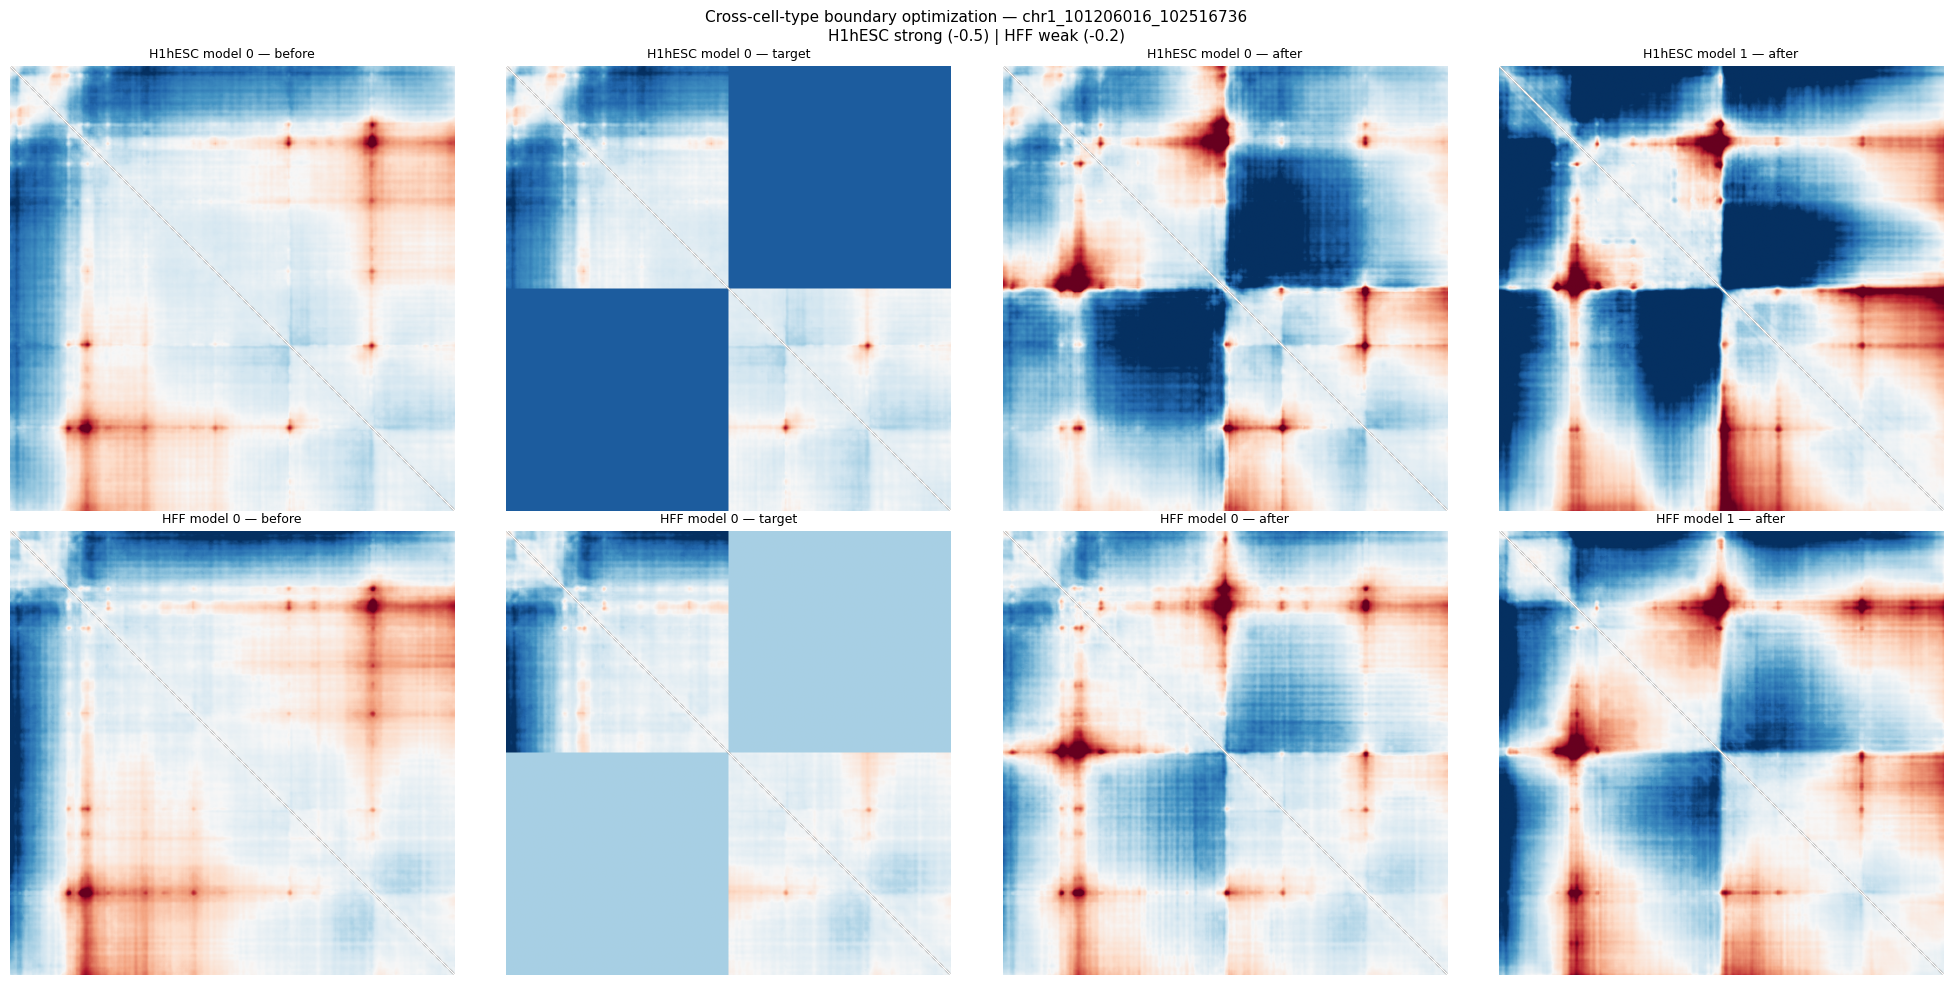

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
row_labels = [
    f"{STRONG_CELL_TYPE} (strong target {STRONG_STRENGTH})",
    f"{WEAK_CELL_TYPE} (weak target {WEAK_STRENGTH})",
]

for row_idx, ct in enumerate(cell_types_ordered):
    # model indices in the combined list: 0,1 for strong CT; 2,3 for weak CT
    slot_offset = row_idx * 2
    m0, m1 = models[slot_offset], models[slot_offset + 1]

    with torch.no_grad():
        y_before = m0(X).squeeze().cpu().numpy()
        y_after0 = m0(X_gen).squeeze().cpu().numpy()
        y_after1 = m1(X_gen).squeeze().cpu().numpy()

    y_target = target[0, slot_offset, :].cpu().numpy()

    for col_idx, (y, title) in enumerate([
        (y_before, f"{ct} model 0 — before"),
        (y_target, f"{ct} model 0 — target"),
        (y_after0, f"{ct} model 0 — after"),
        (y_after1, f"{ct} model 1 — after"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.imshow(from_upper_triu(y, MAP_SIZE, NUM_DIAGS), vmin=VMIN, vmax=VMAX, cmap=CMAP)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=9)

plt.suptitle(
    f"Cross-cell-type boundary optimization — {STEM}\n"
    f"{STRONG_CELL_TYPE} strong ({STRONG_STRENGTH}) | {WEAK_CELL_TYPE} weak ({WEAK_STRENGTH})",
    fontsize=11,
)
plt.tight_layout()
plt.show()